In [1]:
import awkward as ak
import vector
vector.register_awkward()
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import hist
import mplhep as hep
import pandas as pd
hep.style.ROOT
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from plotting import *
print(matplotlib.__version__)

%load_ext autoreload
%autoreload 2

3.9.2


#### Here lies plots for Z_jet events. Edit styles in plotting.py.

In [2]:
def find_nearest(obj1, obj2):
    #### get dRs
    dR = obj1.deltaR(obj2)
    #### mask where dR to self
    dR = ak.where(dR == 0, None, dR)
    idx = ak.argmin(dR, axis=-1)
    nearest_other = obj2[idx]
    return nearest_other

In [3]:
def sigmoid(x ,L, x0, k):
    y = L / (1 + np.exp(-k*(x-x0)))
    return (y)
def get_fracs(radii, weights, weights_orig):
    fracs = []
    for R, weight in zip(radii, weights):
        # print("orig neg weights ", ak.sum(weights<0))
        # print("n orig weights ", len(weights))
        # print("Frac orgi negative weights ", ak.sum(weights_orig<0)/len(weights))
        frac = (1-ak.sum(weight<0)/ak.sum(weights_orig<0))
        fracs.append(round(frac, 2))
    return fracs
def fit_sigmoid(radii, frac, des_frac=25, string=""):
    print(frac)
    ###initial guess
    if frac[0]>1.:
        frac.insert(0, 0)
        radii.insert(0,0)
    p0 = [max(frac), np.median(np.array(radii)),1]
    popt, pcov = curve_fit(sigmoid, np.array(radii), frac, p0)
    L, x0, k = popt
    if (L/(des_frac-k))-1 > 0:
        x = x0-((1/k)*np.log((L/(des_frac))-1))
        print(f"{string} x value where y = {des_frac}: {x}")
    else:
        print(f"No real solution for y = {des_frac} with sigmoid fit.")
    return popt, pcov
# def plot_cellradius_comp():
def sigmoid_Lfixed(x, x0, k, L=100.0):
    # clip exponent to avoid overflow warnings
    z = np.clip(-k*(x-x0), -700, 700)
    return L / (1.0 + np.exp(z))
def fit_sigmoid_fixedL(radii, fracs, L=100.0, des_frac=25):
    # initial guesses
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
    p0 = [np.median(np.array(radii)),1]

    # bounds: x0 within radii range (with padding), k positive
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = ([np.min(radii) - pad, 1e-6], [np.max(radii) + pad, 10.0])

    popt, pcov = curve_fit(lambda x, x0, k: sigmoid_Lfixed(x, x0, k, L=L),
                           radii, fracs, p0=p0, bounds=bounds)

    x0, k = popt
    return (L, x0, k), pcov
def richards(x, x0, k, nu, L=1.0):
    z = -k*(x-x0)
    return L / (1.0 + np.exp(z))**(1.0/nu)
def fit_richards(radii, fracs, L=1.0):
    x0_guess = np.median(radii)
    k_guess  = 2/np.median(radii)
    nu_guess = 1.0
        # optional: let L float, or fix it to max observed
    if L is None:
        L = fracs.max()
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
   
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = (
        [np.min(radii)-pad, 1e-3, 0.05],   # x0, k, nu
        [np.max(radii)+pad, 10.0/np.median(radii), 20.0]
    )

    popt, pcov = curve_fit(lambda x, x0, k, nu: richards(x, x0, k, nu, L=L),
                           radii, fracs, p0=[x0_guess, k_guess, nu_guess], bounds=bounds)
    return (*popt, L), pcov
def richards_x_at_y(y, x0, k, nu, L):
    y = float(y)
    if not (0.0 < y < L) or k == 0 or nu <= 0:
        return np.nan
    arg = (L / y)**nu - 1.0
    if arg <= 0:
        return np.nan
    return x0 - (1.0 / k) * np.log(arg)

In [4]:
def make_df(radii, weights_orig, inputpath0, inputpath1 = "gev_bigR.npy", points = "None"):
    weights = []
    for R in radii:
        str_R = str(R).replace(".", "p")
        weight = np.load(inputpath0+str_R+inputpath1)
        if type(points)!=str:
            weight = fix_weight_length(points, weight, weights_orig)
        weights.append(weight)
    fracs = get_fracs(radii, weights, weights_orig)
    df = pd.DataFrame({
        "radius": radii,
        "fraction": fracs,
        "weights": weights
    })
    return df
def fix_weight_length(points, weights, weights_orig):
    mask = np.all(points == 0, axis=(1, 2))
    if len(weights) != len(weights_orig):
        rw_weights = weights_orig.copy()
        rw_weights[~mask] = weights
        return rw_weights
    else:
        return weights

In [5]:
##### Load jets

zjj_jets = ak.from_parquet('/oscar/data/mleblan6/lhay/zjj_NLO_100k_alljets.parquet')
order = ak.argsort(zjj_jets.pt, axis=1, ascending=False)
zjets = zjj_jets[order]
####load hp points to repopulate weights where the event==0 and those weights were not computed
hp_points = np.load("/oscar/data/mleblan6/rjain/ppzjj_100k/hardprocess_points.npy")
####Load z coords
zpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,0]
zeta = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,1]
zphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,2]



#### load original weights for ttbar, z+jet
N=10000
weights_orig_10k = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy')[N:2*N]
weights_orig_z = np.load("/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy")


#### making the beta=1 hard process dataframe
radii_hp = [5,7,9,9.2,9.5,10,12,12.5,12.9,13.1,15,18,20,25]
zjet_hp_df = make_df(radii_hp, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_hp_emd_reweight_","gev_bigR.npy", points=hp_points)
#### print the available fractions
print(zjet_hp_df["fraction"].values)
#### if you would like to look up by fraction
df_f = zjet_hp_df.set_index("fraction")
w_f = df_f.loc[0.73, "weights"]

#### showered
radii_ps_100k = [5,9,10,12.5,12.6,15,17.2,20,25]
zjet_ps_df = make_df(radii_ps_100k, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_sho_emd_reweight_","gev_bigR.npy")
#### hadronization 
radii_had_100k = [5, 10, 13, 15, 17.2, 20, 25 ]
zjet_had_df = make_df(radii_had_100k, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_had_emd_reweight_","gev_bigR.npy")


###### Camille hard process SEMD RW's
radii_cm_SEMD = [10, 25, 35, 40, 45, 47, 50, 55, 65, 75, 100]
zjet_SEMD_cm = make_df(radii_cm_SEMD, weights_orig_z, "/oscar/data/mleblan6/cell_resampling/SEMD_reweightings/rw_", ".npy")
##### Rishabh SEMD RW's w/ p=1
radii_hp = np.logspace(-5,-2,50)
hp_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/hardprocess_reweights.npy")
hp_rw = np.array([fix_weight_length(hp_points, rw, weights_orig_z) for rw in hp_rw])
fracs = get_fracs(radii_hp, hp_rw, weights_orig_z)
zjet_SEMD_hp_df = pd.DataFrame({"radius": radii_hp, "fraction": fracs, "weights": hp_rw.tolist()})

radii_ps =  np.logspace(-4,-2,50)
ps_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/showered_reweights.npy")
fracs = get_fracs(radii_ps, ps_rw, weights_orig_z)
zjet_SEMD_ps_df = pd.DataFrame({"radius": radii_ps, "fraction": fracs, "weights": ps_rw.tolist()})

had_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/hadronization_reweights.npy")
fracs = get_fracs(radii_ps, had_rw, weights_orig_z)
zjet_SEMD_had_df = pd.DataFrame({"radius": radii_ps, "fraction": fracs, "weights": had_rw.tolist()})

#### beta=0
radii_b0 = np.logspace(1,2.4,50)
b0_hp_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hardprocess_reweights_fixed.npy")
b0_hp_rw = np.array([fix_weight_length(hp_points, rw, weights_orig_z) for rw in b0_hp_rw])
print(b0_hp_rw.shape)
fracs = get_fracs(radii_b0, b0_hp_rw, weights_orig_z)
zjet_b0_hp_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_hp_rw.tolist()})

b0_ps_rw = np.load("/oscar/data/mleblan6/rjain/beta0/showered_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_ps_rw, weights_orig_z)
zjet_b0_ps_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_ps_rw.tolist()})

b0_had_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hadronization_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_had_rw, weights_orig_z)
zjet_b0_had_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_had_rw.tolist()})

#### beta=infinity
radii_binf = np.logspace(-4,-1,50)
binf_hp_rw = np.load("/oscar/data/mleblan6/rjain/betainf/hardprocess_reweights.npy")
binf_hp_rw = np.array([fix_weight_length(hp_points, rw, weights_orig_z) for rw in binf_hp_rw])
fracs = get_fracs(radii_binf, binf_hp_rw, weights_orig_z)
zjet_binf_hp_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_hp_rw.tolist()})

binf_ps_rw = np.load("/oscar/data/mleblan6/rjain/betainf/showered_reweights.npy")
fracs = get_fracs(radii_binf, binf_ps_rw, weights_orig_z)
zjet_binf_ps_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_ps_rw.tolist()})

binf_had_rw = np.load("/oscar/data/mleblan6/rjain/betainf/hadronization_reweights.npy")
fracs = get_fracs(radii_binf, binf_had_rw, weights_orig_z)
zjet_binf_had_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_had_rw.tolist()})

#### z+2jet beta=0.5 dataframes
radii_beta0p5_hp_100k = [10,20,30,40]
radii_beta0p5_hp_100k.sort()
zjet_b0p5_hp_df = make_df(radii_beta0p5_hp_100k, weights_orig_z, "/oscar/data/mleblan6/jmarrinan/hp_reweights/100k_hp_emd_reweight_", "gev_Rmax_beta0p5.npy", points=hp_points)

radii_beta0p5_ps_100k = [25,30,40,50]
zjet_b0p5_ps_df = make_df(radii_beta0p5_ps_100k, weights_orig_z, "/oscar/data/mleblan6/jmarrinan/sho_reweights/100k_shower_emd_reweight_", "gev_Rmax_beta0p5.npy")

radii_beta2_had_100k = [10,20,30,33,40,50, 52]
zjet_b0p5_had_df = make_df(radii_beta2_had_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta0p5/100k_had_emd_b0p5_reweight_", "gev.npy")


#### z+2jet beta=2 dataframes

radii_beta2_hp_100k = [1.03,1.3,1.15,1.41,1.02,1.75,1.5,1.04]
radii_beta2_hp_100k.sort()
zjet_b2_hp_df = make_df(radii_beta2_hp_100k, weights_orig_z, "/oscar/data/mleblan6/jmarrinan/hp_reweights/100k_hp_emd_reweight_", "gev_Rmax_beta2.npy", points=hp_points)

radii_beta2_ps_100k = [1,1.1,1.15,1.2,1.3,1.4,1.5,1.6,1.8,5]
zjet_b2_ps_df = make_df(radii_beta2_ps_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2/100k_ps_emd_b2_reweight_", "gev.npy")

radii_beta2_had_100k = [1.13,1.3,1.5,] #[1,1.1,1.13,1.15,1.2,1.3,1.4,1.5,1.6,1.8,2,3]
zjet_b2_had_df = make_df(radii_beta2_had_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2/100k_had_emd_b2_reweight_", "gev.npy")
### below are beta = 2's that obey the triangle ineq

radii_beta2NEW_ps_100k = [1.0, 1.1, 1.2, 1.3, 1.5,1.6,1.7,1.8,10,100]
zjet_ps_b2_df = make_df(radii_beta2NEW_ps_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_ps_emd_b2NEW_reweight_", "gev.npy", )

radii_beta2RJ_hp_100k = [1.1,1.2,1.3,1.4,1.5,1.6,1.7]
zjet_hp_b2_df = make_df(radii_beta2RJ_hp_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_hp_emd_b2RJ_reweight_", "gev.npy", points=hp_points)

radii_beta2RJ_had_100k = [1.1, 1.2, 1.3]
zjet_had_b2_df = make_df(radii_beta2RJ_had_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_had_emd_b2RJ_reweight_", "gev.npy", )



[0.13 0.26 0.5  0.52 0.55 0.6  0.73 0.76 0.77 0.78 0.85 0.91 0.93 0.97]
(50, 100000)


[0.19 0.29 0.55 0.73] [25 30 40 50]
Z+jets ps beta=0.5 100k R for 0.75 RW  50.964
[0.07 0.2  0.55 0.77] [10 20 30 40]
Z+jets hp beta=0.5 100k R for 0.75 RW  38.32
[0.   0.   0.15 0.25 0.48 0.7  0.73] [10 20 30 33 40 50 52]
Z+jets had beta=0.5 100k R for 0.75 RW  52.2


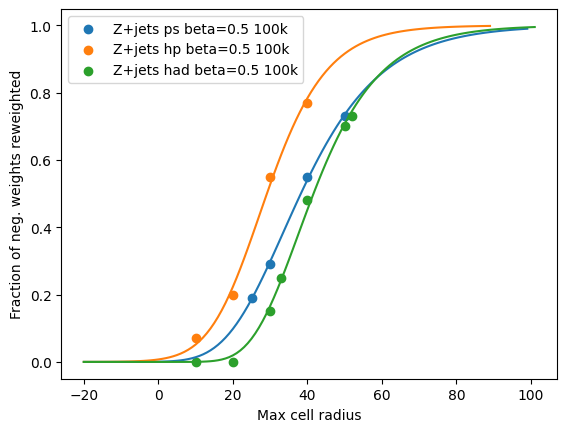

In [6]:
strings = ["Z+jets ps beta=0.5 100k",  "Z+jets hp beta=0.5 100k", "Z+jets had beta=0.5 100k",] 
weights_orig_list = [weights_orig_z, weights_orig_z, weights_orig_z]

rw_dicts = [zjet_b0p5_ps_df, zjet_b0p5_hp_df, zjet_b0p5_had_df, ] 
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    print(frac, radii)
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.arange(-20,np.max(radii)+50)
    frac=0.75
    print(f"{strings[i]} R for {frac} RW ", round(richards_x_at_y(frac, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")
plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

[0.05 0.12 0.21 0.35 0.59 0.68 0.76 0.81 1.   1.  ] [  1.    1.1   1.2   1.3   1.5   1.6   1.7   1.8  10.  100. ]
Z+jets ps beta=2 100k R for 0.25 RW  1.226
[0.28 0.42 0.54 0.65 0.73 0.79 0.84] [1.1 1.2 1.3 1.4 1.5 1.6 1.7]
Z+jets hp beta=2 100k R for 0.25 RW  1.063
[0.1  0.25 0.41] [1.1 1.2 1.3]
Z+jets had beta=2 100k R for 0.25 RW  1.205


/tmp/ipykernel_57330/1845725858.py:69: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(lambda x, x0, k, nu: richards(x, x0, k, nu, L=L),


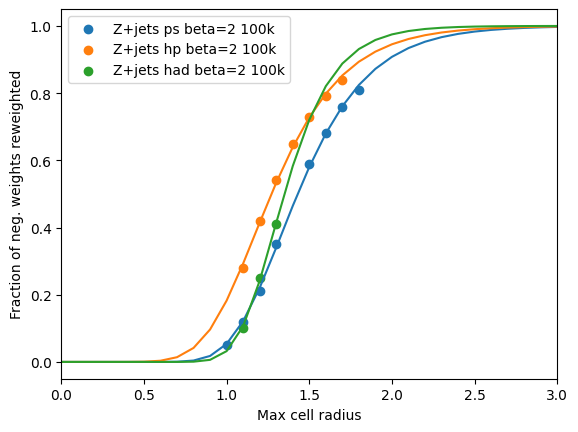

In [7]:
strings = ["Z+jets ps beta=2 100k", "Z+jets hp beta=2 100k", "Z+jets had beta=2 100k"]
weights_orig_list = [weights_orig_z, weights_orig_z, weights_orig_z, weights_orig_z, weights_orig_z, weights_orig_z]

rw_dicts = [zjet_ps_b2_df, zjet_hp_b2_df, zjet_had_b2_df]
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    print(frac, radii)
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.arange(-20,np.max(radii)+50)/10
    frac=0.25
    print(f"{strings[i]} R for {frac} RW ", round(richards_x_at_y(frac, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")
plt.xlim(0, 3)
plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

[0.08 0.18 0.24 0.31 0.46 0.6  0.7  0.78 0.87 1.  ] [1.   1.1  1.15 1.2  1.3  1.4  1.5  1.6  1.8  5.  ]
Z+jets ps beta=2 100k R for 0.50 RW  1.559
[0.25 0.54 0.76] [1.13 1.3  1.5 ]
Z+jets had beta=2 100k R for 0.50 RW  1.478
[0.26 0.28 0.29 0.46 0.66 0.76 0.82 0.91] [1.02 1.03 1.04 1.15 1.3  1.41 1.5  1.75]
Z+jets hp beta=2 100k R for 0.50 RW  1.402
[0.05 0.12 0.21 0.35 0.59 0.68 0.76 0.81 1.   1.  ] [  1.    1.1   1.2   1.3   1.5   1.6   1.7   1.8  10.  100. ]
ps orig R for 0.50 RW  1.685
[0.1  0.25 0.41] [1.1 1.2 1.3]
had orig R for 0.50 RW  1.526
[0.28 0.42 0.54 0.65 0.73 0.79 0.84] [1.1 1.2 1.3 1.4 1.5 1.6 1.7]
hp orig R for 0.50 RW  1.529


/tmp/ipykernel_57330/1845725858.py:69: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(lambda x, x0, k, nu: richards(x, x0, k, nu, L=L),


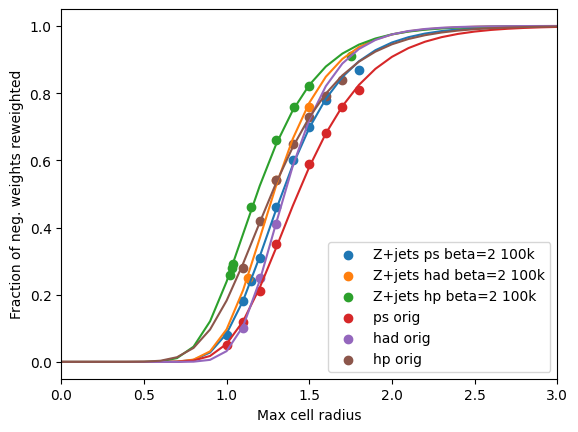

In [8]:
strings = ["Z+jets ps beta=2 100k", "Z+jets had beta=2 100k", "Z+jets hp beta=2 100k", "ps orig", "had orig", "hp orig"]
weights_orig_list = [weights_orig_z, weights_orig_z, weights_orig_z]

rw_dicts = [zjet_b2_ps_df, zjet_b2_had_df, zjet_b2_hp_df, zjet_ps_b2_df, zjet_had_b2_df, zjet_hp_b2_df]
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    print(frac, radii)
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.arange(-20,np.max(radii)+50)/10
    print(f"{strings[i]} R for 0.50 RW ", round(richards_x_at_y(0.75, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")
plt.xlim(0, 3)
plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

[0.01 0.01 0.02 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.12 0.13
 0.15 0.16 0.18 0.2  0.22 0.25 0.28 0.32 0.36 0.4  0.45 0.49 0.54 0.58
 0.62 0.66 0.69 0.73 0.76 0.78 0.81 0.83 0.85 0.87 0.89 0.9  0.91 0.92
 0.93 0.94 0.95 0.96 0.96 0.97 0.97 0.98] [0.0001     0.00010985 0.00012068 0.00013257 0.00014563 0.00015999
 0.00017575 0.00019307 0.0002121  0.000233   0.00025595 0.00028118
 0.00030888 0.00033932 0.00037276 0.00040949 0.00044984 0.00049417
 0.00054287 0.00059636 0.00065513 0.00071969 0.0007906  0.00086851
 0.0009541  0.00104811 0.0011514  0.00126486 0.0013895  0.00152642
 0.00167683 0.00184207 0.00202359 0.002223   0.00244205 0.0026827
 0.00294705 0.00323746 0.00355648 0.00390694 0.00429193 0.00471487
 0.00517947 0.00568987 0.00625055 0.00686649 0.00754312 0.00828643
 0.00910298 0.01      ]
Z+jets ps p=1 SEMD 100k R for 0.50 RW  0.002
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.01 0.01
 0.01 0.02 0.03 0.05 0.07 0.1  0.15 0.2  0.25 0.31 0.37 0.43 0.48 0.54

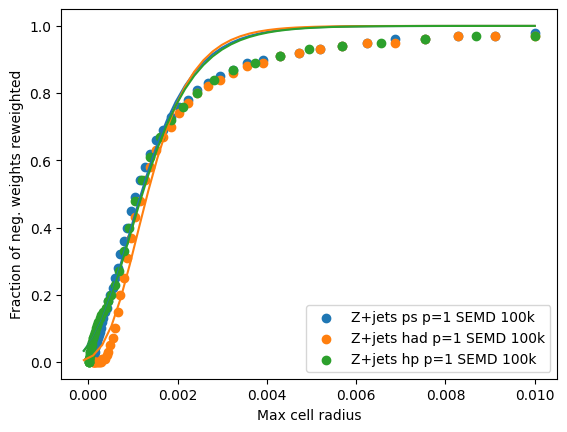

In [9]:
strings = ["Z+jets ps p=1 SEMD 100k", "Z+jets had p=1 SEMD 100k", "Z+jets hp p=1 SEMD 100k"]
weights_orig_list = [weights_orig_z, weights_orig_z, weights_orig_z]

rw_dicts = [zjet_SEMD_ps_df, zjet_SEMD_had_df, zjet_SEMD_hp_df]
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    print(frac, radii)
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.linspace(-0.0001, 0.01, 50)
    print(f"{strings[i]} R for 0.50 RW ", round(richards_x_at_y(0.75, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")
plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.01
 0.01 0.02 0.03 0.04 0.07 0.1  0.16 0.23 0.32 0.41 0.5  0.58 0.66 0.72
 0.77 0.82 0.86 0.89 0.91 0.93 0.95 0.96 0.97 0.98 0.98 0.99 0.99 0.99
 0.99 1.   1.   1.   1.   1.   1.   1.  ] [ 10.          10.68000433  11.40624924  12.18187912  13.01025217
  13.89495494  14.83981789  15.84893192  16.92666615  18.07768677
  19.30697729  20.6198601   22.0220195   23.51952635  25.11886432
  26.82695795  28.6512027   30.59949687  32.68027589  34.90254879
  37.2759372   39.81071706  42.51786303  45.40909611  48.49693429
  51.79474679  55.31681198  59.07837912  63.09573445  67.38627168
  71.9685673   76.862461    82.0891416   87.67123873  93.63292088
 100.         106.80004325 114.06249239 121.8187912  130.10252169
 138.94954944 148.3981789  158.48931925 169.2666615  180.7768677
 193.06977289 206.19860095 220.220195   235.19526351 251.18864315]
Z+jets $\beta=0$ Hadronization R for 0.50 RW  61.159
[0.   0.26 0.55 0.68 0.77 0.85 0

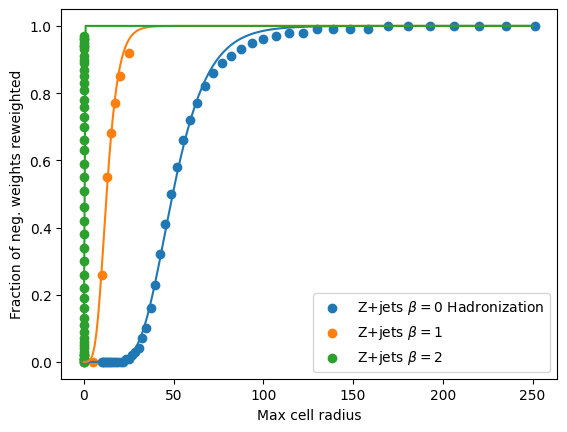

In [10]:
strings = [r"Z+jets $\beta=0$ Hadronization", r"Z+jets $\beta=1$", r"Z+jets $\beta=2$"]
weights_orig_list = [weights_orig_z, weights_orig_z, weights_orig_z]

rw_dicts = [zjet_b0_had_df, zjet_had_df, zjet_binf_had_df]
cmap  = cm.tab10.colors 

for i, df in enumerate(rw_dicts):
    frac = df["fraction"].values
    radii = df["radius"].values
    print(frac, radii)
    plt.scatter(radii, frac, color=cmap[i], label = strings[i])
    popt, pcov = fit_richards(radii, frac)
    x = np.linspace(-0.0001, 250, 251)
    print(f"{strings[i]} R for 0.50 RW ", round(richards_x_at_y(0.75, *popt), 3))
    plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
plt.xlabel("Max cell radius")
plt.ylabel("Fraction of neg. weights reweighted")
plt.legend()

In [11]:
from plotting import *

[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.01
 0.01 0.02 0.03 0.04 0.07 0.1  0.16 0.23 0.32 0.41 0.5  0.58 0.66 0.72
 0.77 0.82 0.86 0.89 0.91 0.93 0.95 0.96 0.97 0.98 0.98 0.99 0.99 0.99
 0.99 1.   1.   1.   1.   1.   1.   1.  ]
[0.   0.   0.15 0.25 0.48 0.7  0.73]
[0.   0.26 0.55 0.68 0.77 0.85 0.92]
[0.25 0.54 0.76]
[0.   0.   0.   0.01 0.01 0.01 0.01 0.02 0.02 0.02 0.03 0.04 0.05 0.06
 0.07 0.09 0.11 0.13 0.16 0.19 0.22 0.26 0.3  0.34 0.38 0.42 0.46 0.51
 0.55 0.59 0.63 0.66 0.7  0.73 0.76 0.78 0.81 0.83 0.85 0.87 0.89 0.9
 0.91 0.93 0.94 0.94 0.95 0.96 0.96 0.97]
89538
100000


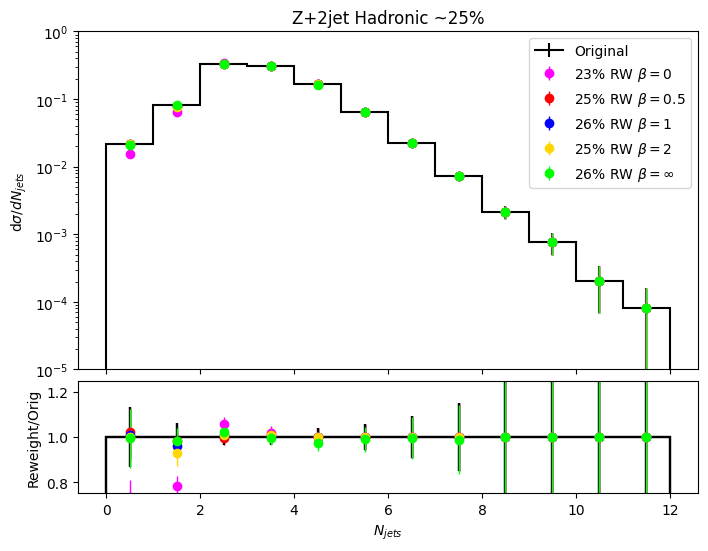

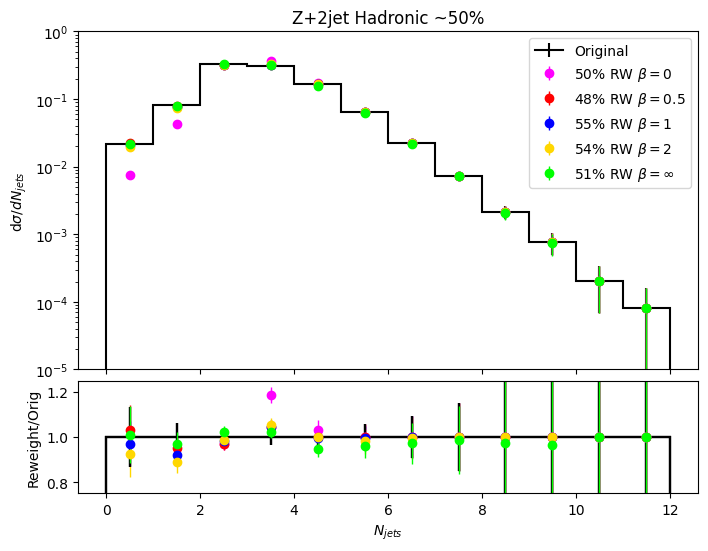

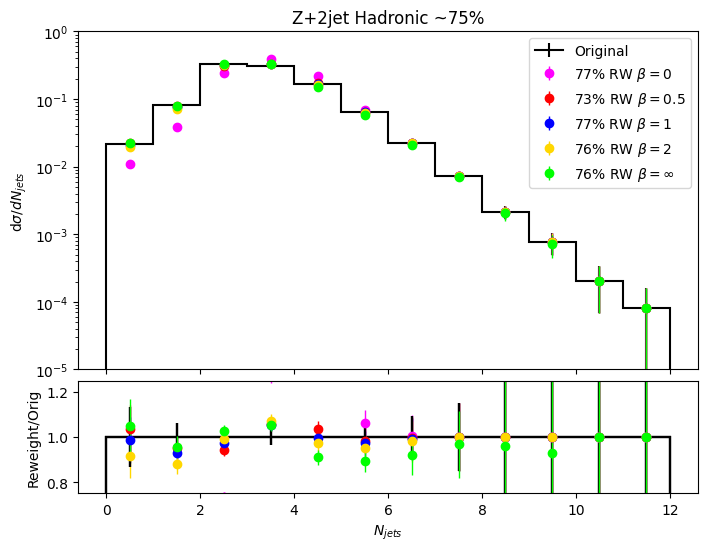

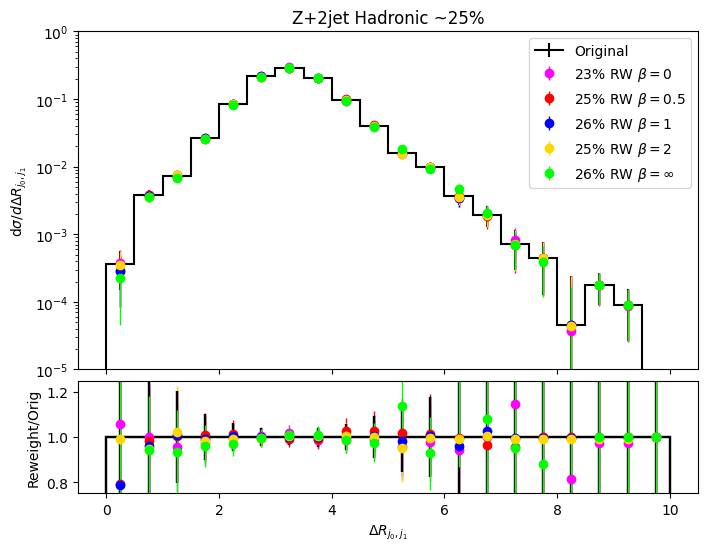

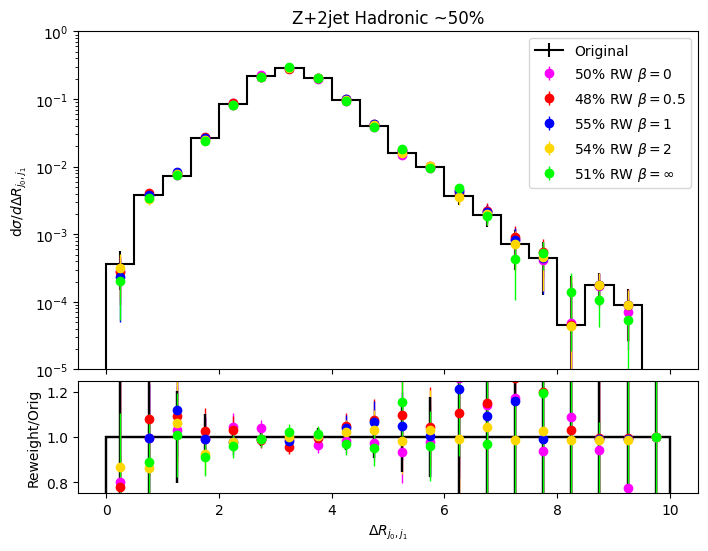

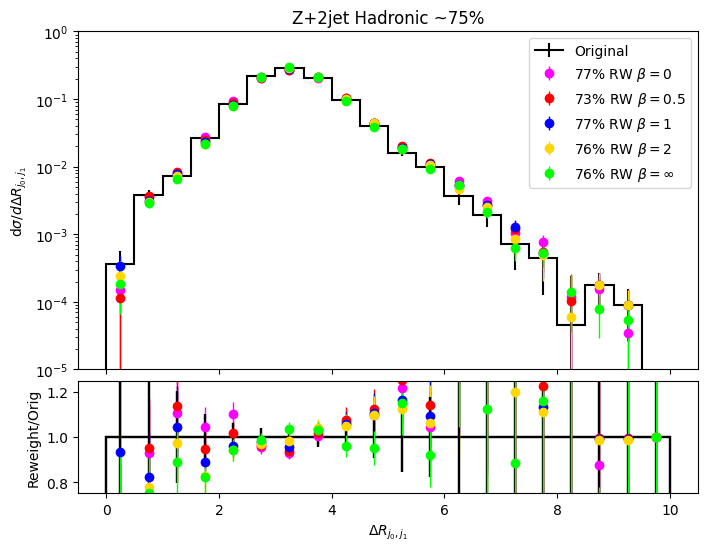

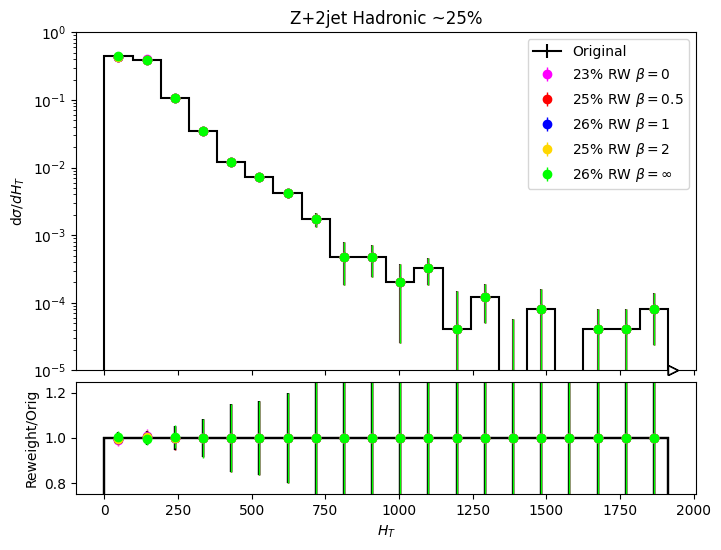

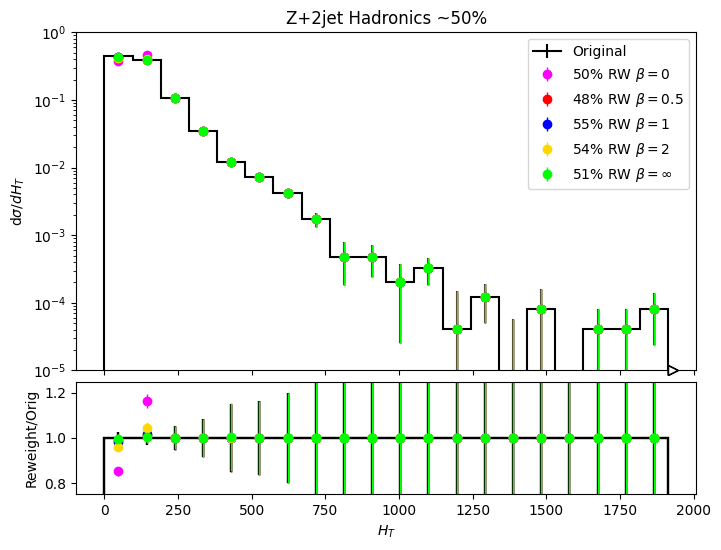

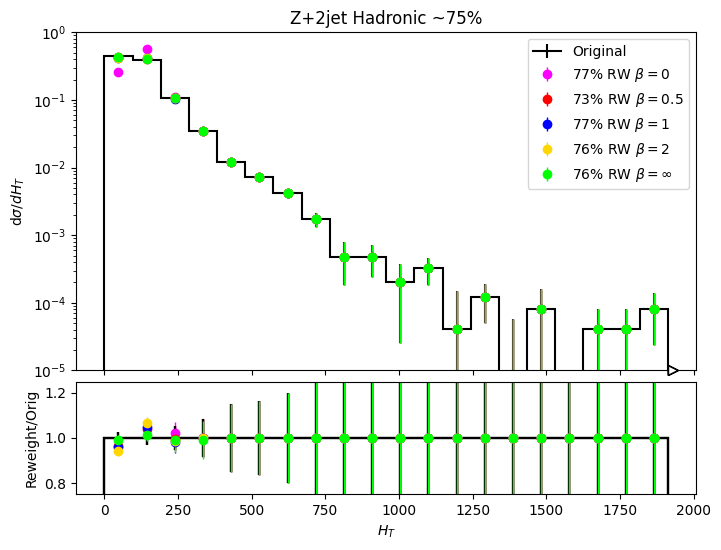

In [12]:
process_str = [r"$\beta=0$",   r"$\beta=0.5$",r"$\beta=1$",r"$\beta=2$", r"$\beta=\infty$"]
print(zjet_b0_had_df["fraction"].values)
print(zjet_b0p5_had_df["fraction"].values)
print(zjet_had_df["fraction"].values)
print(zjet_b2_had_df["fraction"].values)
print(zjet_binf_had_df["fraction"].values)
fracs_25 = [0.23, 0.25,0.26, 0.25,  0.26]
fracs_50 = [0.5, 0.48,0.55,  0.54,  0.51]
fracs_75 = [0.77, 0.73,0.77, 0.76,  0.76]
dfs = [zjet_b0_had_df, zjet_b0p5_had_df, zjet_had_df, zjet_b2_had_df,  zjet_binf_had_df]
quantity = "N_{jets}"
njets = ak.num(zjets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax
plot_diff_rw(obs, dfs, process_str, fracs_25, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronic ~25%", raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronic ~50%", raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_75, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronic ~75%", raxlim=[0.75, 1.25])
quantity = r"\Delta R_{j_0, j_1}"
xmin = 0
xmax = 10  
numbins=20
sel = (ak.num(zjets.pt, axis=1)>1)
sel_jets = zjets[sel]
obs= np.sqrt((sel_jets.eta[:,0] - sel_jets.eta[:,1])**2 + (sel_jets.phi[:,0] - sel_jets.phi[:,1])**2)
print(len(obs))
plot_diff_rw(obs, dfs, process_str, fracs_25, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronic ~25%", sel=sel, raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronic ~50%", sel=sel, raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_75, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronic ~75%", sel=sel, raxlim=[0.75, 1.25])
quantity = r"H_T"

obs= ak.sum(zjets.pt, axis=-1)
xmin = 0
xmax = int(max(obs))  
numbins=20
print(len(obs))
plot_diff_rw(obs, dfs, process_str, fracs_25, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronic ~25%",  raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronics ~50%", raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_75, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet Hadronic ~75%", raxlim=[0.75, 1.25])

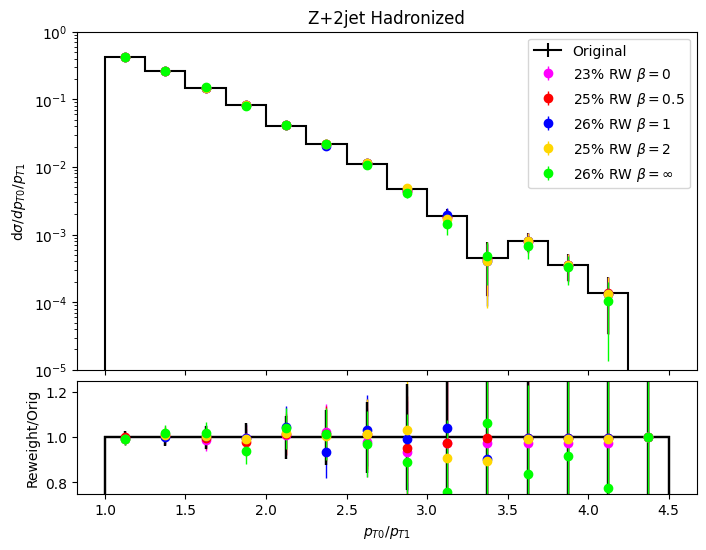

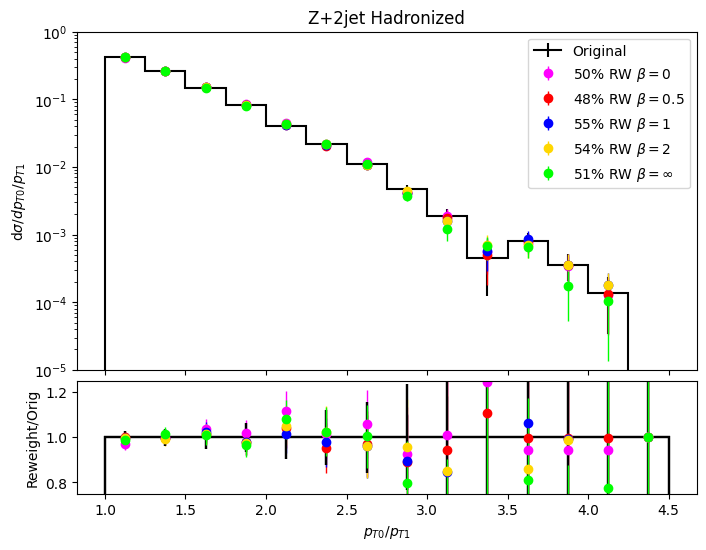

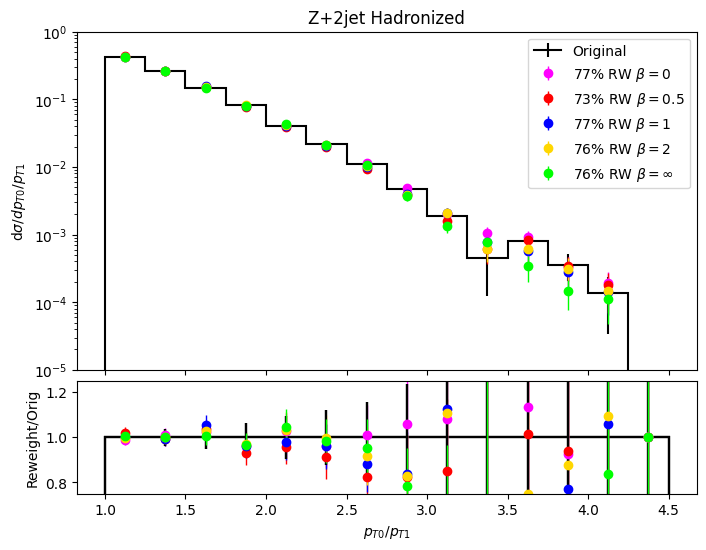

In [13]:
obs_str = 'p_{T0}/p_{T1}' #string for labels and stuff is the observable
numbins = 14 #number of bins
xmin = 1
xmax=4.5
sel = (ak.num(zjets.pt, axis=1)>1)
sel_jets = zjets[sel]
obs = sel_jets.pt[:,0]/sel_jets.pt[:,1]
plot_diff_rw(obs, dfs, process_str, fracs_25, weights_orig_z, xmin, xmax, numbins, obs_str = obs_str, title = "Z+2jet Hadronized", raxlim=[0.75, 1.25], sel=sel)
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_z, xmin, xmax, numbins, obs_str = obs_str, title = "Z+2jet Hadronized", raxlim=[0.75, 1.25], sel=sel)
plot_diff_rw(obs, dfs, process_str, fracs_75, weights_orig_z, xmin, xmax, numbins, obs_str = obs_str, title = "Z+2jet Hadronized", raxlim=[0.75, 1.25], sel=sel)

100000


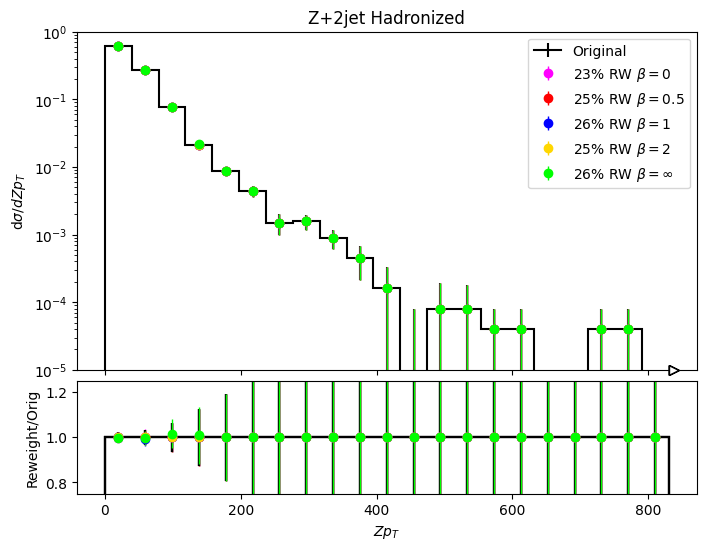

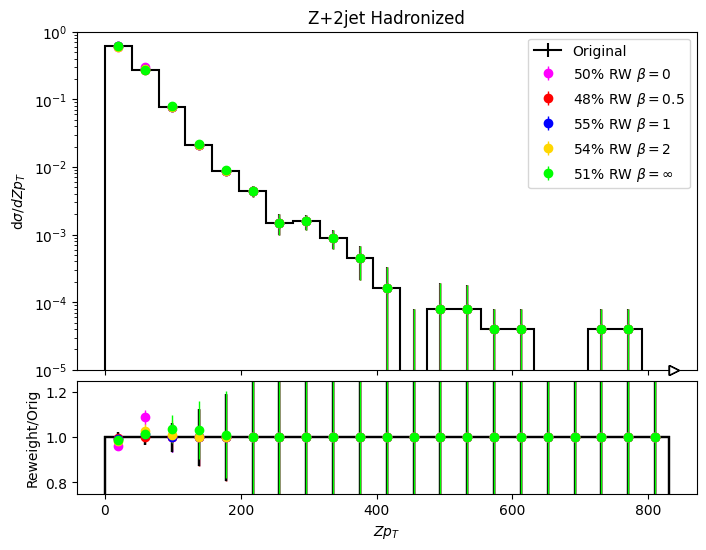

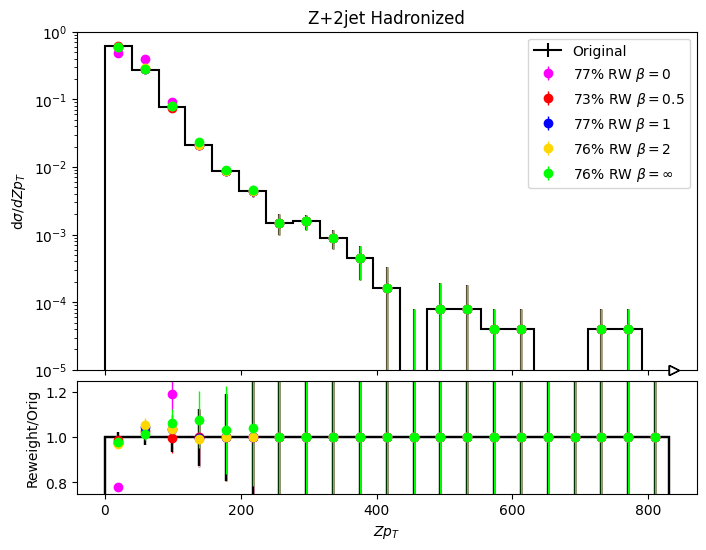

In [14]:
obs_str = 'Z p_T' #string for labels and stuff is the observable
numbins = 21 #number of bins
xmin = 0
xmax = max(zpt)
print(len(zpt))
obs = zpt
plot_diff_rw(obs, dfs, process_str, fracs_25, weights_orig_z, xmin, xmax, numbins, obs_str = obs_str, title = "Z+2jet Hadronized", raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_z, xmin, xmax, numbins, obs_str = obs_str, title = "Z+2jet Hadronized", raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_75, weights_orig_z, xmin, xmax, numbins, obs_str = obs_str, title = "Z+2jet Hadronized", raxlim=[0.75, 1.25])

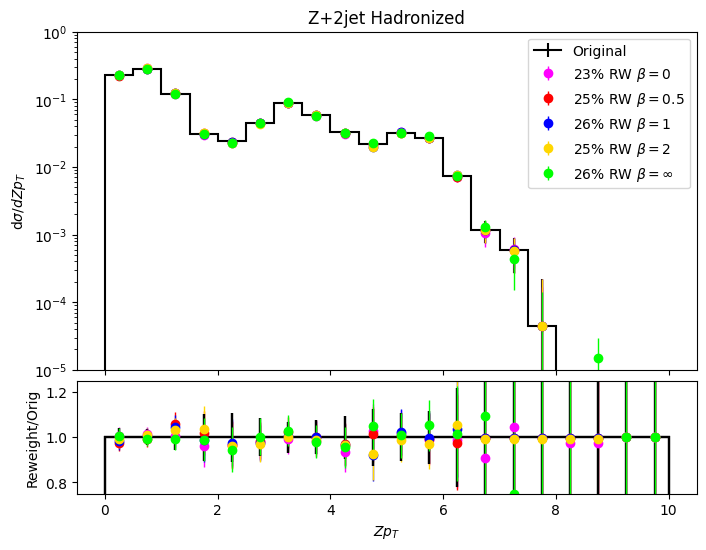

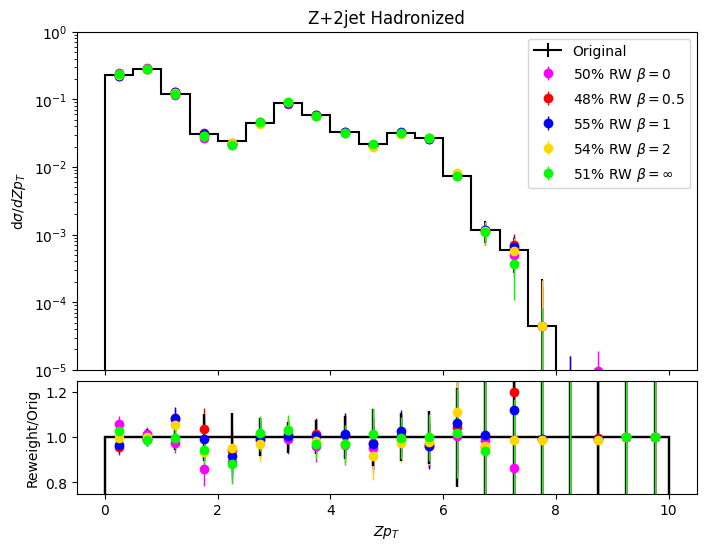

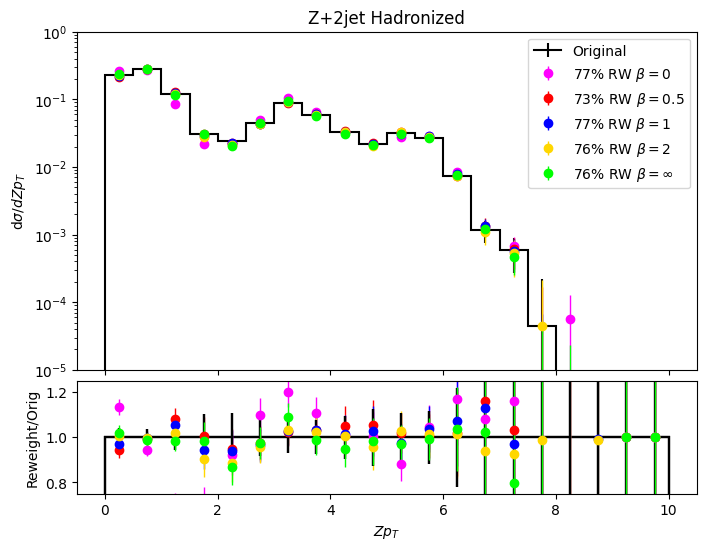

In [15]:
quantity = r"\Delta R_{j_0, j_1}"
xmin = 0
xmax = 10  
numbins=20
sel = (ak.num(zjets.pt, axis=1)>1)
sel_jets = zjets[sel]
obs= np.sqrt((sel_jets.eta[:,0] - zeta[sel])**2 + (sel_jets.phi[:,0] - zphi[sel])**2)
plot_diff_rw(obs, dfs, process_str, fracs_25, weights_orig_z, xmin, xmax, numbins, sel=sel,obs_str = obs_str, title = "Z+2jet Hadronized", raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_z, xmin, xmax, numbins, sel=sel,obs_str = obs_str, title = "Z+2jet Hadronized", raxlim=[0.75, 1.25])
plot_diff_rw(obs, dfs, process_str, fracs_75, weights_orig_z, xmin, xmax, numbins, sel=sel,obs_str = obs_str, title = "Z+2jet Hadronized", raxlim=[0.75, 1.25])

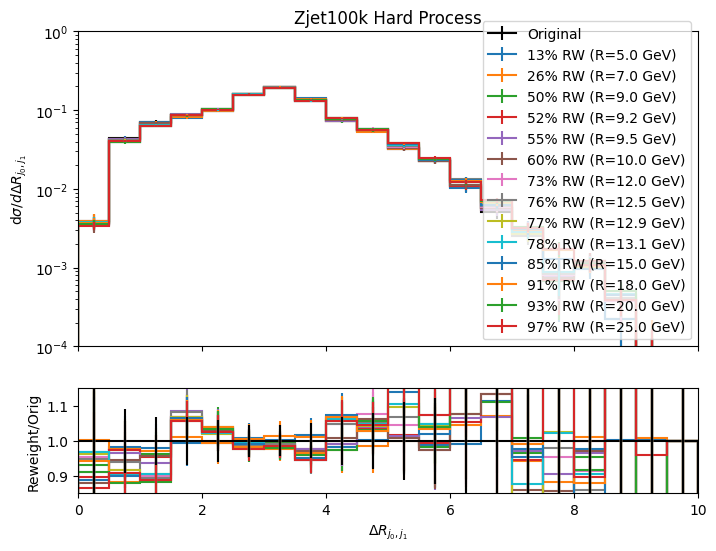

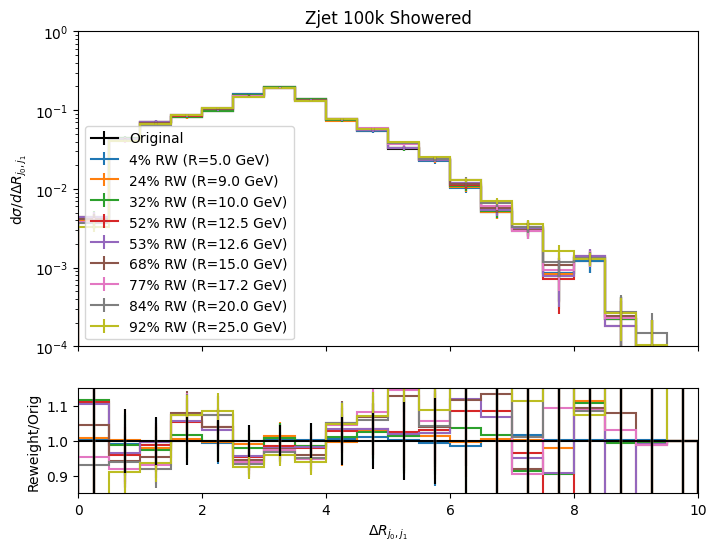

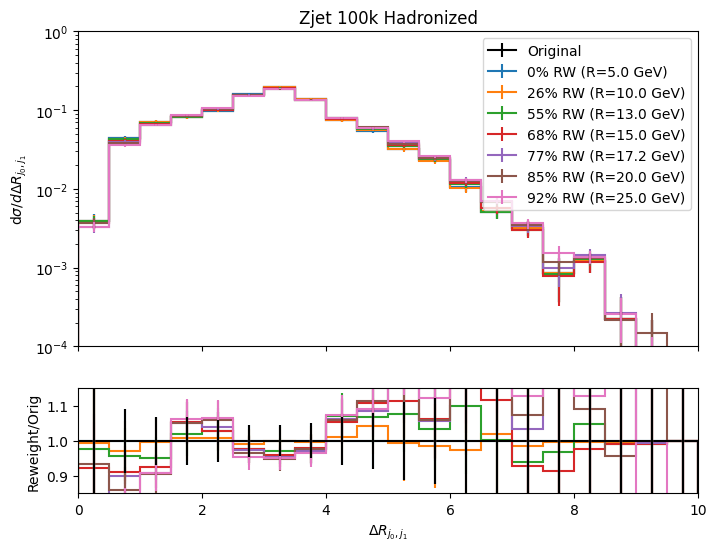

In [16]:
quantity = r"\Delta R_{j_0, j_1}"
xmin = 0
xmax = 10  
numbins=20

sel = (ak.num(zjets.pt, axis=1)>1)
sel_jets = zjets[sel]
obs= np.sqrt((sel_jets.eta[:,-1] - sel_jets.eta[:,-2])**2 + (sel_jets.phi[:,-1] - sel_jets.phi[:,-2])**2)

dfs = [zjet_hp_df, zjet_ps_df, zjet_had_df]
plot_same_rw_all(obs, dfs[0], weights_orig_z, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "Zjet100k Hard Process")
plot_same_rw_all(obs, dfs[1], weights_orig_z, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "Zjet 100k Showered")
plot_same_rw_all(obs, dfs[2], weights_orig_z, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "Zjet 100k Hadronized")

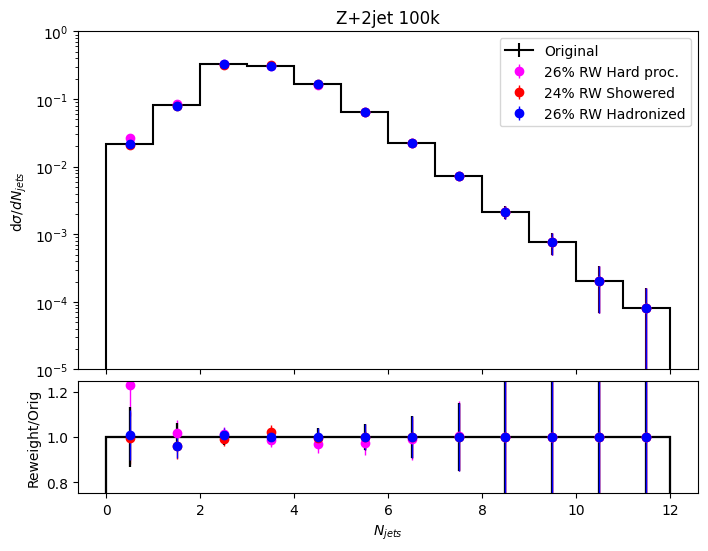

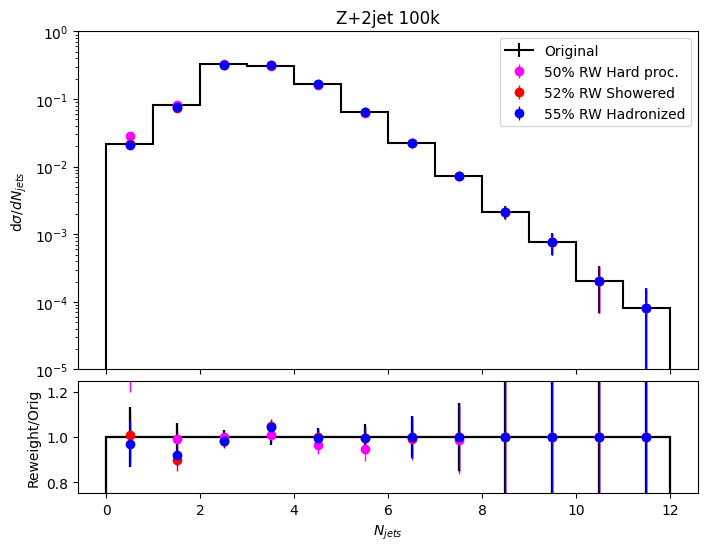

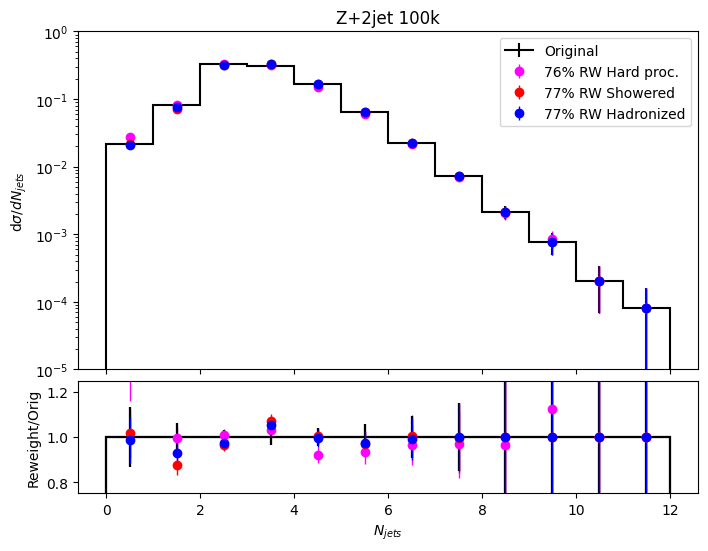

In [17]:
process_str = ["Hard proc.", "Showered", "Hadronized"]

fracs = [0.26, 0.24, 0.26]
dfs = [zjet_hp_df, zjet_ps_df, zjet_had_df]
quantity = "N_{jets}"
njets = ak.num(zjets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet 100k")
fracs = [0.5, 0.52, 0.55]
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet 100k")
fracs = [0.76, 0.77, 0.77]
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet 100k")

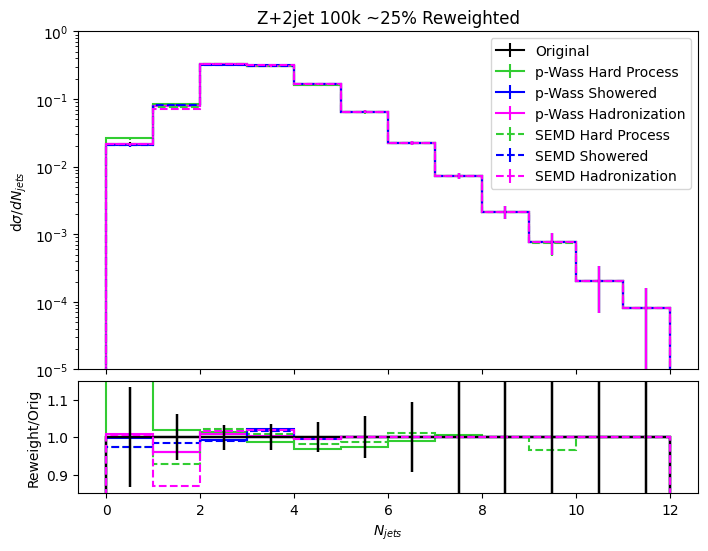

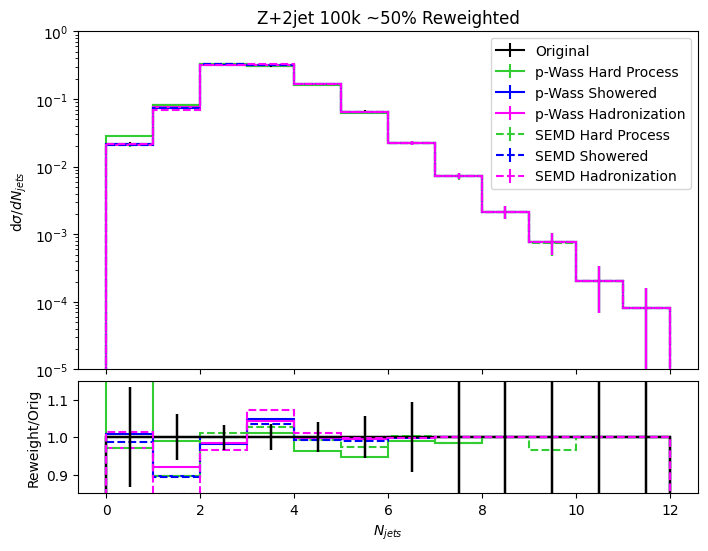

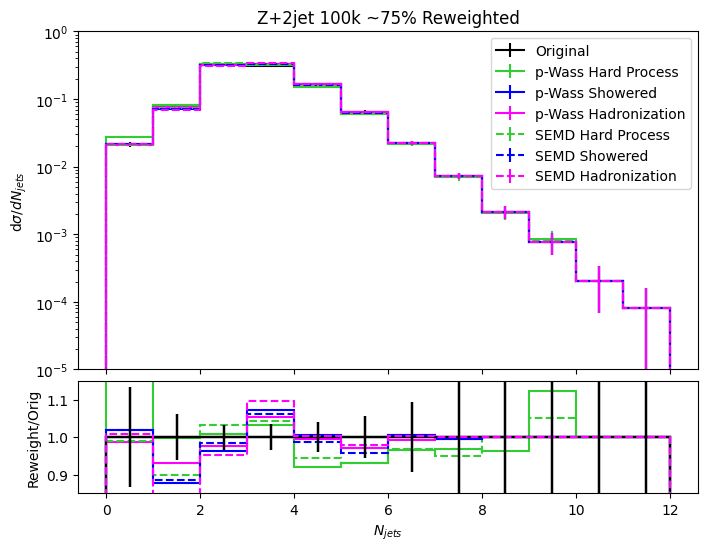

In [18]:
coll_str = ["p-Wass", "SEMD"]
process_str = ["Hard Process", "Showered", "Hadronization"]
quantity = "N_{jets}"
njets = ak.num(zjets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax

fracs_emd = [0.26, 0.24, 0.26]
fracs_semd = [0.27, 0.25, 0.25]
fracs = [fracs_emd, fracs_semd]
dfs_emd = [zjet_hp_df, zjet_ps_df, zjet_had_df,]
dfs_semd = [ zjet_SEMD_hp_df,zjet_SEMD_ps_df, zjet_SEMD_had_df]
dfs = [dfs_emd, dfs_semd]
plot_collection(obs, dfs, coll_str, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet 100k ~25% Reweighted", cmap = ["limegreen", "blue", "magenta"])

fracs_emd = [0.5, 0.52, 0.55]
fracs_semd = [0.48, 0.49, 0.54]
fracs = [fracs_emd, fracs_semd]
plot_collection(obs, dfs, coll_str, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet 100k ~50% Reweighted", cmap = ["limegreen", "blue", "magenta"])

fracs_emd = [0.76, 0.77, 0.77]
fracs_semd = [0.76, 0.76, 0.77]
fracs = [fracs_emd, fracs_semd]
plot_collection(obs, dfs, coll_str, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, title = "Z+2jet 100k ~75% Reweighted", cmap = ["limegreen", "blue", "magenta"])


89538


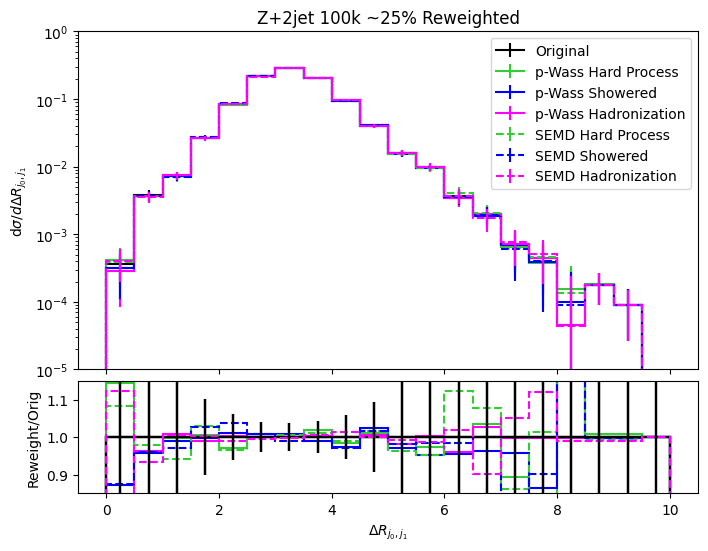

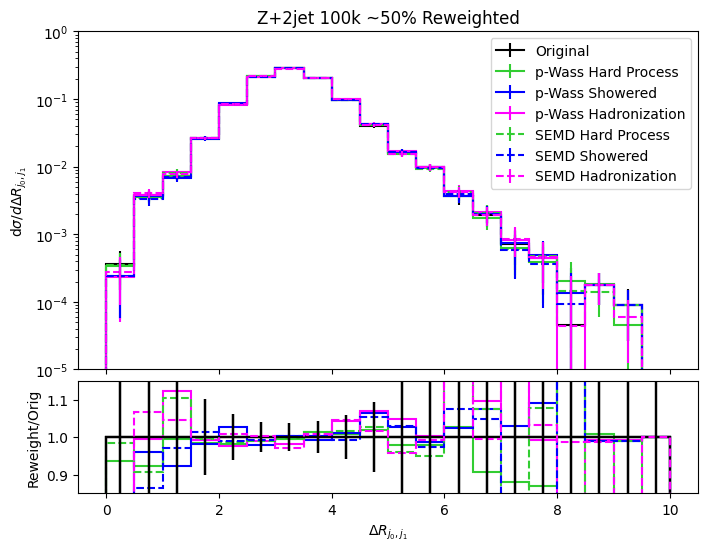

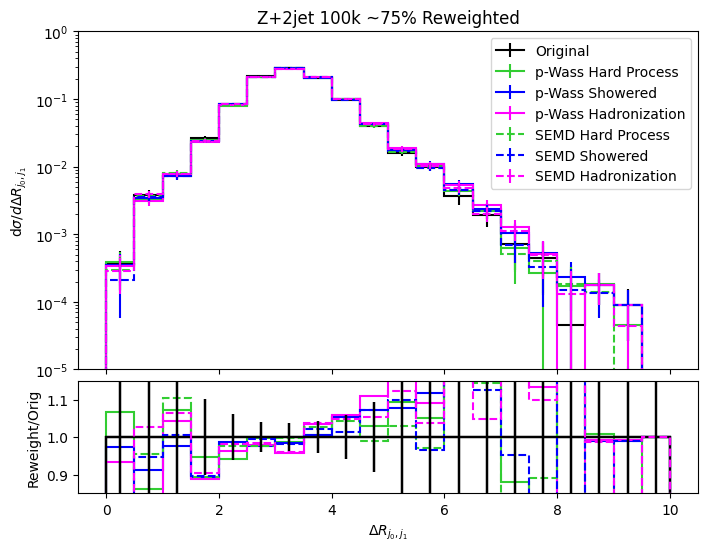

In [19]:
quantity = r"\Delta R_{j_0, j_1}"
xmin = 0
xmax = 10  
numbins=20
sel = (ak.num(zjets.pt, axis=1)>1)
sel_jets = zjets[sel]
obs= np.sqrt((sel_jets.eta[:,0] - sel_jets.eta[:,1])**2 + (sel_jets.phi[:,0] - sel_jets.phi[:,1])**2)
print(len(obs))

fracs_emd = [0.26, 0.24, 0.26]
fracs_semd = [0.27, 0.25, 0.25]
fracs = [fracs_emd, fracs_semd]
dfs_emd = [zjet_hp_df, zjet_ps_df, zjet_had_df,]
dfs_semd = [ zjet_SEMD_hp_df,zjet_SEMD_ps_df, zjet_SEMD_had_df]
dfs = [dfs_emd, dfs_semd]
plot_collection(obs, dfs, coll_str, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity,sel=sel, title = "Z+2jet 100k ~25% Reweighted", cmap = ["limegreen", "blue", "magenta"])

fracs_emd = [0.5, 0.52, 0.55]
fracs_semd = [0.48, 0.49, 0.54]
fracs = [fracs_emd, fracs_semd]
plot_collection(obs, dfs, coll_str, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, sel=sel, title = "Z+2jet 100k ~50% Reweighted", cmap = ["limegreen", "blue", "magenta"])

fracs_emd = [0.76, 0.77, 0.77]
fracs_semd = [0.76, 0.76, 0.77]
fracs = [fracs_emd, fracs_semd]
plot_collection(obs, dfs, coll_str, process_str, fracs, weights_orig_z, xmin, xmax, numbins, obs_str = quantity, sel=sel, title = "Z+2jet 100k ~75% Reweighted", cmap = ["limegreen", "blue", "magenta"])


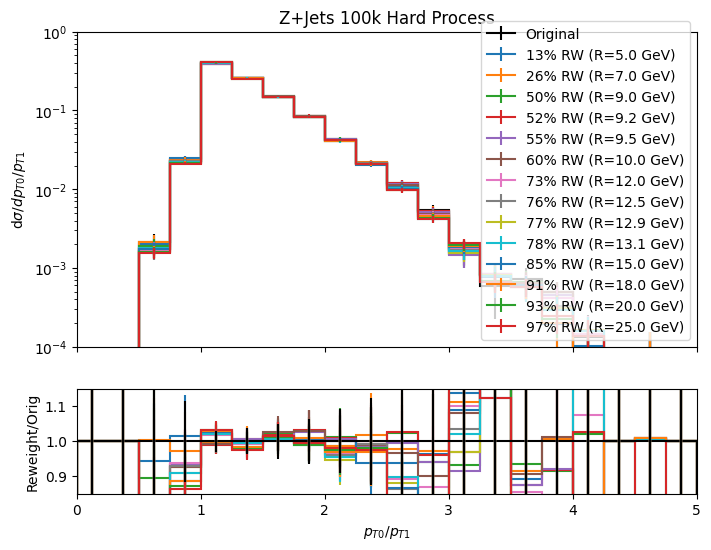

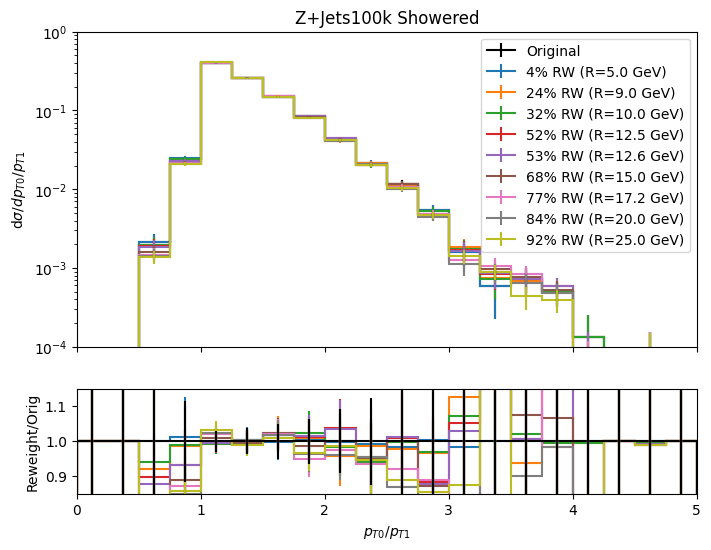

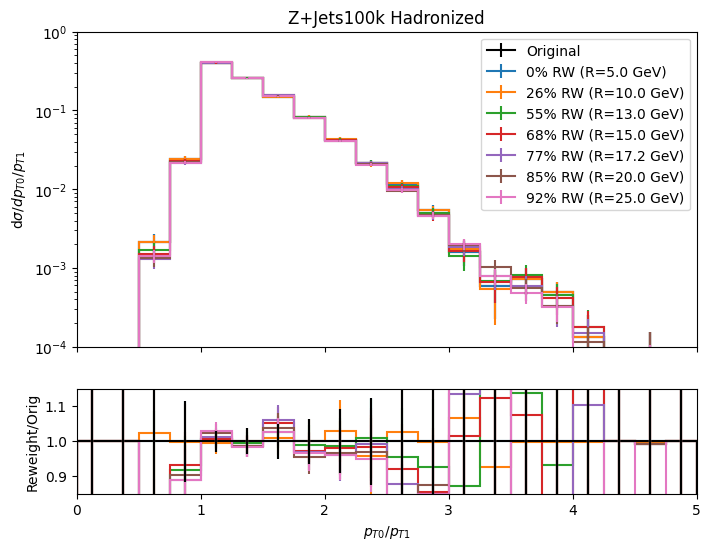

In [20]:
### plot pt ratio of leading and subleading jet
# from plotting import *
obs_str = 'p_{T0}/p_{T1}' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin = 0
xmax=5
sel = (ak.num(zjj_jets.pt, axis=1)>1)
sel_jets = zjj_jets[sel]
obs = sel_jets.pt[:,-1]/sel_jets.pt[:,-2]
plot_same_rw_all(obs, zjet_hp_df, weights_orig_z, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "Z+Jets 100k Hard Process")
plot_same_rw_all(obs, zjet_ps_df, weights_orig_z, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "Z+Jets100k Showered")
plot_same_rw_all(obs, zjet_had_df, weights_orig_z, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "Z+Jets100k Hadronized")

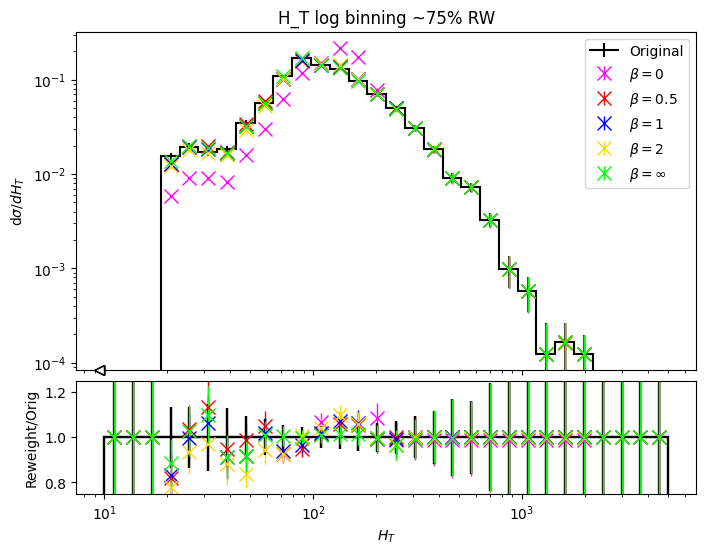

In [21]:
##### custom HT plot w/ log x axis
obs_str = r"H_T"
dfs = [zjet_b0_had_df, zjet_b0p5_had_df, zjet_had_df, zjet_b2_had_df,  zjet_binf_had_df]
strings = [r"$\beta=0$",   r"$\beta=0.5$",r"$\beta=1$",r"$\beta=2$", r"$\beta=\infty$"]
title = "H_T log binning ~75% RW"
plot_opts = {
        'linestyle': 'none',
        'marker': 'x',
        'markersize': 10.,
        'elinewidth': 1,
    }
# fracs_25 = [0.23, 0.25,0.26, 0.25,  0.26]
# fracs_50 = [0.5, 0.48,0.55,  0.54,  0.51]
fracs = [0.77, 0.73,0.77, 0.76,  0.76]
obs= ak.sum(zjets.pt, axis=-1)
xmin = 10
xmax = 5e3
nbins= 30
fig, (ax, rax) = plt.subplots(nrows=2,
                    ncols=1,
                    figsize=(8,6),
                    gridspec_kw={"height_ratios": (3, 1)},
                    sharex=True)
######## when we initialize the hist axis this is where we tell it to transform to a log binning
h_orig = hist.Hist(
    hist.axis.Regular(nbins,xmin, xmax, transform=hist.axis.transform.log),
    storage=hist.storage.Weight(), )
h_orig.fill(obs, weight = weights_orig_z)
h_orig = h_orig/h_orig.sum(flow=False).value
hep.histplot(h_orig, ax=ax, label = "Original", color='black')
for i, df in enumerate(dfs):
    weights = np.array(df.loc[df["fraction"]==fracs[i], "weights"].squeeze())
    h = hist.Hist(
        hist.axis.Regular(nbins,xmin, xmax,name="data",label="reweighted",transform=hist.axis.transform.log),
        storage=hist.storage.Weight(), 
    )
    h.fill(obs, weight = weights)
    #### Normalize hists
    h = h/h.sum(flow=False).value
    bin_centers = h.axes[0].centers
    bin_edges = h.axes[0].edges
    ratio, ratio_unc = get_ratio_unc(h, h_orig)
    ratio1, ratio_unc1 = get_ratio_unc(h_orig, h_orig)
    ######## plot_opts that we defined above defines out plot style
    hep.histplot(np.ones_like(ratio), bins=bin_edges, ax=rax, yerr = np.sqrt(ratio_unc1), color='black', histtype="step")
    hep.histplot(ratio, bins=bin_edges, ax=rax,  color=cmap[i], histtype='errorbar', yerr = np.sqrt(ratio_unc), **plot_opts)
    hep.histplot(h, ax=ax, label = f"{strings[i]}", color=cmap[i],  histtype='errorbar', **plot_opts)
rax.set_xlabel(rf"${obs_str}$")
rax.set_ylabel("Reweight/Orig")
ax.set_title(title)
ax.set_ylabel(rf"d$\sigma/d{obs_str}$")
ax.set_xlabel(None)
rax.set_ylim(0.75,1.25)
ax.legend()
ax.set_yscale('log')
plt.subplots_adjust(hspace=0.05)
ax.set_xscale("log")
rax.set_xscale("log")

[   10.            12.68961003    16.10262028    20.43359718
    25.92943797    32.90344562    41.75318937    52.98316906
    67.23357536    85.31678524   108.26367339   137.38237959
   174.33288222   221.22162911   280.72162039   356.22478903
   452.03536564   573.61525104   727.8953844    923.67085719
  1172.10229753  1487.35210729  1887.39182214  2395.02661999
  3039.19538231  3856.62042116  4893.90091848  6210.16941892
  7880.46281567 10000.        ]


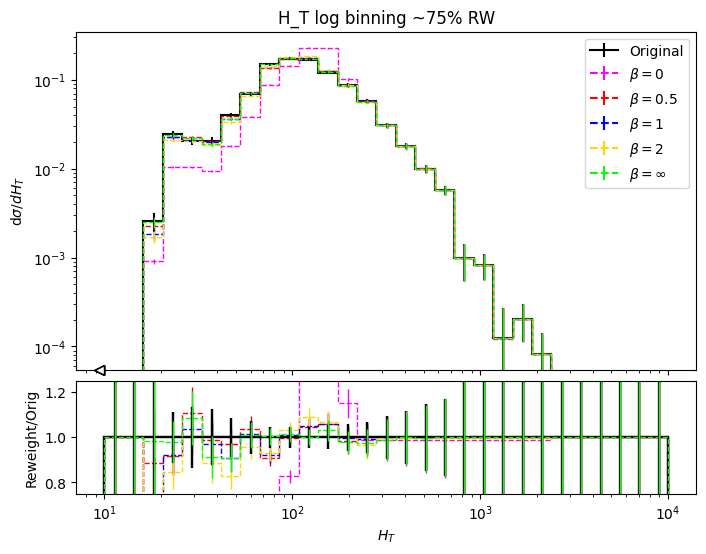

In [22]:
##### Alternatively, we could make a custom binning in a log scale as well
obs_str = r"H_T"
dfs = [zjet_b0_had_df, zjet_b0p5_had_df, zjet_had_df, zjet_b2_had_df,  zjet_binf_had_df]
strings = [r"$\beta=0$",   r"$\beta=0.5$",r"$\beta=1$",r"$\beta=2$", r"$\beta=\infty$"]
title = "H_T log binning ~75% RW"
plot_opts = {
        'histtype':'step',
        'linestyle': '--',
        #'marker': 'none', ####if hist type is step, cannot give a markersize or style
        #'markersize': 'none',
        'linewidth':1,
        #'elinewidth': 1,
    }
# fracs_25 = [0.23, 0.25,0.26, 0.25,  0.26]
# fracs_50 = [0.5, 0.48,0.55,  0.54,  0.51]
fracs = [0.77, 0.73,0.77, 0.76,  0.76]
obs= ak.sum(zjets.pt, axis=-1)
fig, (ax, rax) = plt.subplots(nrows=2,
                    ncols=1,
                    figsize=(8,6),
                    gridspec_kw={"height_ratios": (3, 1)},
                    sharex=True)
######## when we initialize the hist axis we instead use variable binning and give is the log bin bounds
edges = np.logspace(1, 4, num=30) 
print(edges)
h_orig = hist.Hist(
       hist.axis.Variable(edges),
    storage=hist.storage.Weight(), )
h_orig.fill(obs, weight = weights_orig_z)
h_orig = h_orig/h_orig.sum(flow=False).value
hep.histplot(h_orig, ax=ax, label = "Original", color='black')
for i, df in enumerate(dfs):
    weights = np.array(df.loc[df["fraction"]==fracs[i], "weights"].squeeze())
    ######## match binning style in the reweighted hists 
    h = hist.Hist(
        hist.axis.Variable(edges,name="data",label="reweighted"),
        storage=hist.storage.Weight(), 
    )
    h.fill(obs, weight = weights)
    #### Normalize hists
    h = h/h.sum(flow=False).value
    bin_centers = h.axes[0].centers
    bin_edges = h.axes[0].edges
    ratio, ratio_unc = get_ratio_unc(h, h_orig)
    ratio1, ratio_unc1 = get_ratio_unc(h_orig, h_orig)
    ##### **plot_opts hold the style options we decided above
    hep.histplot(np.ones_like(ratio), bins=bin_edges, ax=rax, yerr = np.sqrt(ratio_unc1), color='black', histtype="step")
    hep.histplot(ratio, bins=bin_edges, ax=rax,  color=cmap[i], yerr = np.sqrt(ratio_unc), **plot_opts)
    hep.histplot(h, ax=ax, label = f"{strings[i]}", color=cmap[i],  **plot_opts)
rax.set_xlabel(rf"${obs_str}$")
rax.set_ylabel("Reweight/Orig")
ax.set_title(title)
ax.set_ylabel(rf"d$\sigma/d{obs_str}$")
ax.set_xlabel(None)
rax.set_ylim(0.75,1.25)
ax.legend()
ax.set_yscale('log')
plt.subplots_adjust(hspace=0.05)
ax.set_xscale("log")
rax.set_xscale("log")